# Bijectors and Transformed Distributions

ProbPipe's `TransformedDistribution` applies a TFP bijector to any base distribution, producing a new distribution with transformed support. This enables constrained parameterizations like log-normal, sigmoid-bounded, and more.

This notebook builds on concepts from [01_distributions.ipynb](01_distributions.ipynb).

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import tensorflow_probability.substrates.jax.bijectors as tfb

from probpipe import (
    Normal, MultivariateNormal, Beta, Gamma,
    EmpiricalDistribution, TransformedDistribution,
    Provenance, provenance_ancestors,
)
from probpipe.core.distribution import real, positive, unit_interval
from probpipe import log_prob, mean, prob, sample, variance

key = jax.random.PRNGKey(0)

## What is a Bijector?

A **bijector** is an invertible, differentiable function $f : \mathbb{R}^n \to \mathbb{R}^n$. TFP provides many useful bijectors: `Exp`, `Sigmoid`, `Softplus`, `Shift`, `Scale`, and more.

When applied to a distribution, a bijector transforms the support and adjusts the density via the **change-of-variables formula**. If $X \sim p_X$ and $Y = f(X)$, then:

$$p_Y(y) = p_X\bigl(f^{-1}(y)\bigr) \cdot \left|\det \frac{\partial f^{-1}}{\partial y}\right|$$

The Jacobian correction is handled automatically by `TransformedDistribution`.

## Basic Example: Log-Normal via Exp

Applying the `Exp` bijector to a `Normal` distribution gives a log-normal distribution, since if $X \sim \text{Normal}(\mu, \sigma)$, then $e^X \sim \text{LogNormal}(\mu, \sigma)$.

Base support:        real
Transformed support: positive
Event shape:         ()


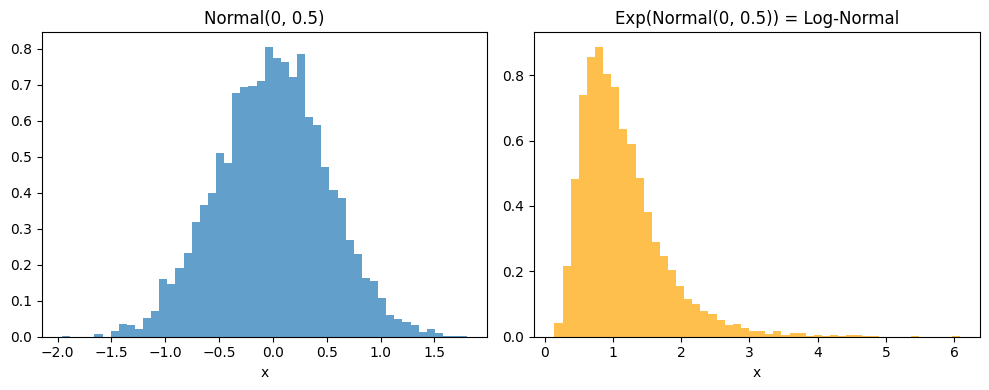

In [2]:
base = Normal(loc=0.0, scale=0.5)
log_normal = TransformedDistribution(base, tfb.Exp(), name="log_normal")

print(f"Base support:        {base.support}")
print(f"Transformed support: {log_normal.support}")
print(f"Event shape:         {log_normal.event_shape}")

# Sample and compare
samples_base = sample(base, key=key, sample_shape=(5000,))
samples_transformed = sample(log_normal, key=key, sample_shape=(5000,))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(samples_base, bins=50, density=True, alpha=0.7)
ax1.set_title("Normal(0, 0.5)")
ax1.set_xlabel("x")

ax2.hist(samples_transformed, bins=50, density=True, alpha=0.7, color="orange")
ax2.set_title("Exp(Normal(0, 0.5)) = Log-Normal")
ax2.set_xlabel("x")
plt.tight_layout()
plt.show()

## Density Evaluation

`log_prob(dist, x)` automatically applies the inverse transform and adds the log-absolute-determinant of the Jacobian correction. This means you can evaluate the density of the transformed distribution directly, without manually computing the Jacobian.

In [ ]:
x = jnp.linspace(0.01, 5.0, 200)
lp = jax.vmap(lambda v: log_prob(log_normal, v))(x)

# Analytical log-normal: loc=0, scale=0.5
import jax.scipy.stats as jstats
lp_analytical = jstats.norm.logpdf(jnp.log(x), 0.0, 0.5) - jnp.log(x)

plt.plot(x, jnp.exp(lp), label="TransformedDistribution", linewidth=2)
plt.plot(x, jnp.exp(lp_analytical), '--', label="Analytical log-normal", linewidth=2)
plt.xlabel("x")
plt.ylabel("density")
plt.title("TransformedDistribution matches analytical log-normal")
plt.legend()
plt.show()

## Sigmoid Transform: Bounded Distributions

The `Sigmoid` bijector maps $\mathbb{R} \to (0, 1)$. Applying it to a Normal distribution produces a distribution with support on the unit interval.

Support: unit_interval


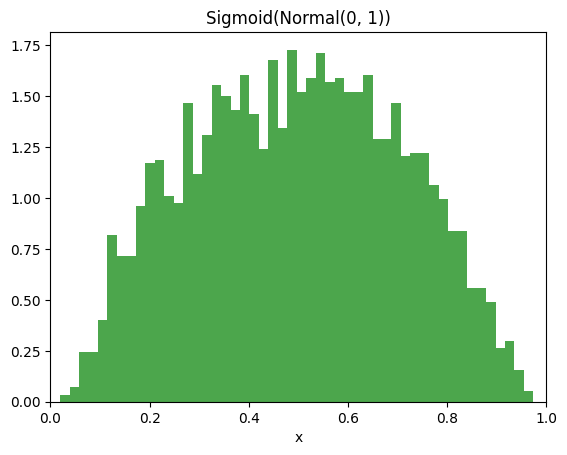

In [4]:
base = Normal(loc=0.0, scale=1.0)
bounded = TransformedDistribution(base, tfb.Sigmoid())

print(f"Support: {bounded.support}")
samples = sample(bounded, key=key, sample_shape=(3000,))

plt.hist(samples, bins=50, density=True, alpha=0.7, color="green")
plt.title("Sigmoid(Normal(0, 1))")
plt.xlabel("x")
plt.xlim(0, 1)
plt.show()

## Softplus Transform: Positive Distributions

The `Softplus` bijector is a smooth approximation of ReLU: $\text{softplus}(x) = \log(1 + e^x)$. It maps $\mathbb{R} \to (0, \infty)$, providing a smooth way to enforce positivity.

Support: positive


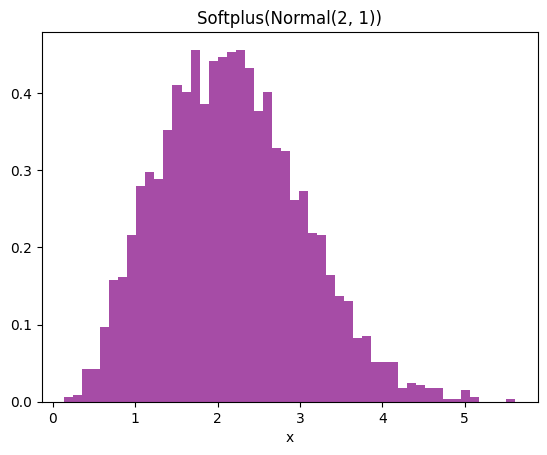

In [5]:
base = Normal(loc=2.0, scale=1.0)
pos = TransformedDistribution(base, tfb.Softplus())

print(f"Support: {pos.support}")
samples = sample(pos, key=key, sample_shape=(3000,))

plt.hist(samples, bins=50, density=True, alpha=0.7, color="purple")
plt.title("Softplus(Normal(2, 1))")
plt.xlabel("x")
plt.show()

## Multivariate Transforms

Bijectors also work on multivariate distributions. Here we apply `Exp` element-wise to a bivariate normal, producing a correlated multivariate log-normal.

Event shape: (2,)


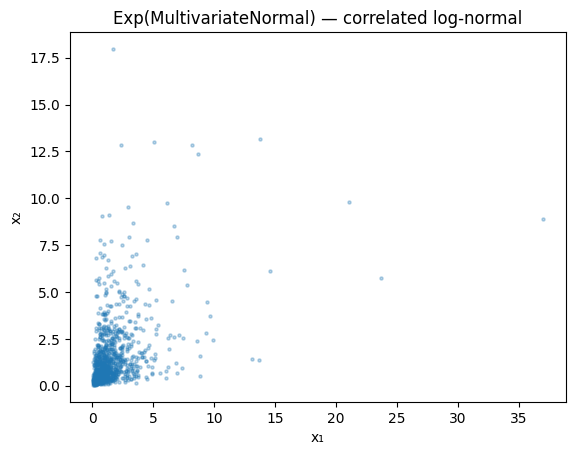

In [6]:
mvn = MultivariateNormal(loc=jnp.zeros(2), cov=jnp.array([[1.0, 0.5], [0.5, 1.0]]))
mvn_exp = TransformedDistribution(mvn, tfb.Exp())

print(f"Event shape: {mvn_exp.event_shape}")
samples = sample(mvn_exp, key=key, sample_shape=(1000,))

plt.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=5)
plt.title("Exp(MultivariateNormal) — correlated log-normal")
plt.xlabel("x\u2081")
plt.ylabel("x\u2082")
plt.show()

## Chaining Bijectors

`tfb.Chain` composes multiple bijectors into a single bijector. Bijectors in the list are applied in **reverse order**: the last element in the list is applied first.

For example, `Chain([Exp, Shift(1), Scale(2)])` means: first scale by 2, then shift by 1, then exponentiate.

Support: positive
Min sample: 0.0011 (should be > 0)


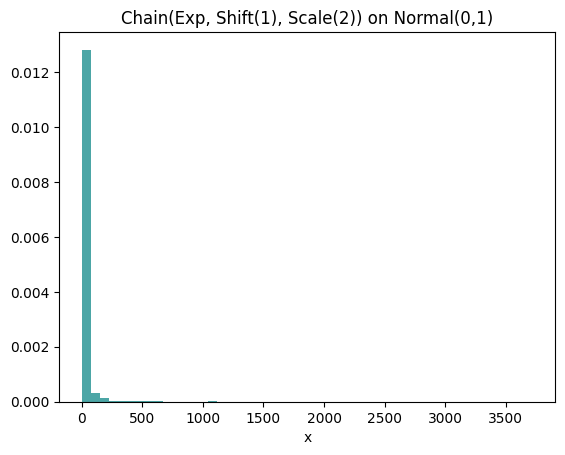

In [7]:
# Scale -> Shift -> Exp: first scale by 2, shift by 1, then exponentiate
chain = tfb.Chain([tfb.Exp(), tfb.Shift(1.0), tfb.Scale(2.0)])
base = Normal(loc=0.0, scale=1.0)
td = TransformedDistribution(base, chain)

samples = sample(td, key=key, sample_shape=(3000,))
print(f"Support: {td.support}")
print(f"Min sample: {float(jnp.min(samples)):.4f} (should be > 0)")

plt.hist(samples, bins=50, density=True, alpha=0.7, color="teal")
plt.title("Chain(Exp, Shift(1), Scale(2)) on Normal(0,1)")
plt.xlabel("x")
plt.show()

## Transforming Non-TFP Distributions

`TransformedDistribution` also works with `EmpiricalDistribution` (which is not TFP-backed). In this case:

- **Sampling**: the bijector's `forward` is applied element-wise to resampled points from the empirical distribution.
- **`log_prob`**: uses the empirical distribution's Gaussian-approximation density at the inverse-transformed point, plus the log-absolute Jacobian correction.

This is useful when you have posterior samples from MCMC or importance sampling and want to work in a transformed space (e.g., enforcing positivity on parameters that were sampled in unconstrained space).

Base empirical: 500 samples, event_shape=(1,)
Transformed:    event_shape=(1,), support=positive
All positive?   True


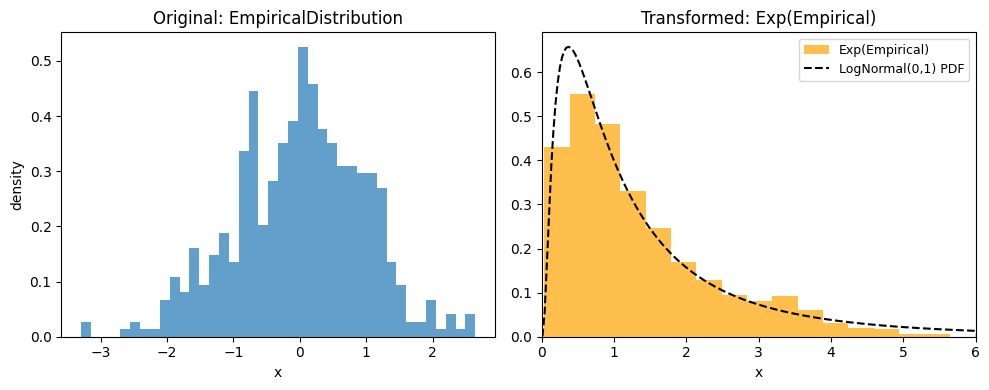

In [8]:
# Create empirical samples from a Normal(0, 1)
n = Normal(loc=0.0, scale=1.0)
emp_samples = sample(n, key=key, sample_shape=(500,))
emp = EmpiricalDistribution(emp_samples.reshape(-1, 1), name="normal_samples")

# Apply Exp bijector — transforms real-valued samples to positive reals
emp_exp = TransformedDistribution(emp, tfb.Exp())
new_samples = sample(emp_exp, key=jax.random.PRNGKey(1), sample_shape=(1000,))

print(f"Base empirical: {emp.n} samples, event_shape={emp.event_shape}")
print(f"Transformed:    event_shape={emp_exp.event_shape}, support={emp_exp.support}")
print(f"All positive?   {bool(jnp.all(new_samples > 0))}")

# Compare: original empirical samples vs. transformed samples
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(emp_samples, bins=40, density=True, alpha=0.7, label="Empirical (Normal)")
ax1.set_title("Original: EmpiricalDistribution")
ax1.set_xlabel("x")
ax1.set_ylabel("density")

ax2.hist(new_samples[:, 0], bins=40, density=True, alpha=0.7, color="orange",
         label="Exp(Empirical)")
# Overlay the analytical log-normal PDF for comparison
x_pos = jnp.linspace(0.01, 6.0, 200)
import jax.scipy.stats as jstats
lp_ref = jstats.norm.logpdf(jnp.log(x_pos), 0.0, 1.0) - jnp.log(x_pos)
ax2.plot(x_pos, jnp.exp(lp_ref), 'k--', linewidth=1.5, label="LogNormal(0,1) PDF")
ax2.set_title("Transformed: Exp(Empirical)")
ax2.set_xlabel("x")
ax2.set_xlim(0, 6)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Available Bijectors

TFP provides a rich library of bijectors. Here are some of the most useful ones:

| Bijector | Mapping | Use case |
|----------|---------|----------|
| `Exp` | $\mathbb{R} \to (0, \infty)$ | Positive parameters (variances, rates) |
| `Log` | $(0, \infty) \to \mathbb{R}$ | Inverse of Exp |
| `Sigmoid` | $\mathbb{R} \to (0, 1)$ | Probabilities, bounded parameters |
| `Softplus` | $\mathbb{R} \to (0, \infty)$ | Smooth positive constraint |
| `Shift(c)` | $x \mapsto x + c$ | Location shifts |
| `Scale(s)` | $x \mapsto s \cdot x$ | Scale adjustments |
| `Chain([...])` | Composition | Combine multiple bijectors |
| `ScaleMatvecTriL(L)` | $x \mapsto L x$ | Lower-triangular linear transform |
| `FillTriangular` | Vector $\to$ lower-triangular matrix | Parameterizing Cholesky factors |
| `CorrelationCholesky` | Unconstrained $\to$ correlation matrix | Correlation modeling |

## Provenance Tracking

Every `TransformedDistribution` automatically records how it was created — which base distribution and which bijector were used. This lets you trace the full lineage of any distribution.

In [9]:
# Build a multi-step provenance chain using successive transformations
base = Normal(loc=0.0, scale=1.0, name="prior")
shifted = TransformedDistribution(base, tfb.Shift(1.0), name="shifted")
positive = TransformedDistribution(shifted, tfb.Exp(), name="positive")

# Each step records its immediate parent and bijector
print(f"positive.source: {positive.source}")
print(f"  bijector: {positive.source.metadata['bijector']}, parent: {positive.source.parents[0].name}")
print(f"shifted.source:  {shifted.source}")
print(f"  bijector: {shifted.source.metadata['bijector']}, parent: {shifted.source.parents[0].name}")

# Trace full ancestry: positive → shifted → prior
ancestors = provenance_ancestors(positive)
print(f"\nFull lineage of '{positive.name}': {[a.name for a in ancestors]}")

# Serialization captures the recursive chain
print(f"\nSerialized:\n{positive.source.to_dict()}")

positive.source: Provenance('transform', parents=[shifted])
  bijector: Exp, parent: shifted
shifted.source:  Provenance('transform', parents=[prior])
  bijector: Shift, parent: prior

Full lineage of 'positive': ['shifted', 'prior']

Serialized:
{'operation': 'transform', 'parents': [{'type': 'TransformedDistribution', 'name': 'shifted', 'source': {'operation': 'transform', 'parents': [{'type': 'Normal', 'name': 'prior'}], 'metadata': {'bijector': 'Shift'}}}], 'metadata': {'bijector': 'Exp'}}


## Summary

Key takeaways:

- **`TransformedDistribution(base, bijector)`** creates a new distribution by applying a bijector to a base distribution.
- Works with any ProbPipe distribution as the base, including TFP-backed distributions and `EmpiricalDistribution`.
- **`log_prob(dist, x)`** includes automatic Jacobian correction via the change-of-variables formula.
- **Support is derived automatically** for common bijectors (`Exp` $\to$ positive, `Sigmoid` $\to$ unit interval, etc.).
- Bijectors can be **chained** via `tfb.Chain` for complex transformations.